# 05 - Cannibalization 

When an article is discounted, do its similar non-discounted articles ("exposed" articles) lose sales?

1. Read the exposed articles and the settings that notebook 04 saved (same weeks, same matching)
2. For every exposed article, pick 5 similar clean controls (same rules as 04)
3. Difference-in-differences: (exposed after - before) - (controls after - before)
4. Cannibalized units = minus the total adjusted change of the exposed articles. An article exposed to 2 discounts is counted once.

Writes to the silver schema:
| Table | Contents |
|---|---|
| `hnm_cannibalization_pair_effects` | discounted article, exposed article, score, change in units (split if an article has several discounted anchors) |
| `hnm_cannibalization_did` | one row with the result |
| `parallel_trends_cannibalization` | average units per week, exposed vs controls (for the chart) |

In [0]:
%pip install -q statsmodels
%pip install -q seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

In [0]:
# Settings (everything else is read from notebook 04's result table so the two notebooks always agree)
dbutils.widgets.text("embeddings_schema", "workspace.hnm_discount")        # written by notebook 03
dbutils.widgets.text("output_schema", "workspace.hnm_discount_silver")     # same schema as notebook 04

embeddings_schema = dbutils.widgets.get("embeddings_schema")
output_schema = dbutils.widgets.get("output_schema")

embeddings_table = f"{embeddings_schema}.hnm_article_text_embeddings"
article_table = f"{output_schema}.hnm_article_treatment_weekly"
units_long_table = f"{output_schema}.hnm_units_long"
exposure_pairs_table = f"{output_schema}.hnm_exposure_pairs"
did_results_table = f"{output_schema}.hnm_incremental_demand_did"

pair_effects_table = f"{output_schema}.hnm_cannibalization_pair_effects"
cannib_results_table = f"{output_schema}.hnm_cannibalization_did"
parallel_trends_table = f"{output_schema}.parallel_trends_cannibalization"

def save_table(pdf, name):
    spark.createDataFrame(pdf).write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(name)
    print("wrote", name)

In [0]:
# Settings from notebook 04
settings = spark.table(did_results_table).toPandas().iloc[0]
treatment_week = int(settings["treatment_week"])
retained_pre = [int(w) for w in str(settings["retained_pre_weeks"]).split(",")]
n_controls_per_exposed = int(settings["n_controls_per_treated"])
lam_level = float(settings["lam_level"])
lam_slope = float(settings["lam_slope"])
print("treatment week:", treatment_week, "| weeks used as 'before':", retained_pre)

# Data from notebook 04
articles = spark.table(article_table).select("article_id", "T").toPandas()
units_long = spark.table(units_long_table).toPandas()
exposure_pairs = spark.table(exposure_pairs_table).toPandas()

units = units_long.pivot(index="article_id", columns="week", values="Y")

treatment week: 5 | weeks used as 'before': [1, 2, 3, 4]


In [0]:
# Features: sales level and trend before the discount (same as 04)
pre = units[retained_pre].to_numpy(dtype=float)
x = np.array(retained_pre, dtype=float)
x = x - x.mean()

feat = pd.DataFrame(index=units.index)
feat["pre_units"] = pre.mean(axis=1)
feat["post_units"] = units[treatment_week].to_numpy(dtype=float)
feat["log_level"] = np.log1p(feat["pre_units"])
feat["slope"] = (np.log1p(pre) * x).sum(axis=1) / (x ** 2).sum()

emb = (spark.table(embeddings_table)
       .select(F.col("article_id").cast("string").alias("article_id"), F.col("text_embedding").alias("embedding"))
       .toPandas().drop_duplicates("article_id").set_index("article_id"))

# Exposed articles (the same set 04 kept out of its controls) and clean controls
exposed_all = set(exposure_pairs["candidate_id"])
not_discounted = set(articles.loc[articles["T"] == 0, "article_id"])

exposed_ids = sorted(exposed_all & set(emb.index) & set(feat.index))
control_ids = sorted((not_discounted - exposed_all) & set(emb.index) & set(feat.index))

pairs = exposure_pairs[exposure_pairs["candidate_id"].isin(exposed_ids)].copy()
anchors_per_article = pairs.groupby("candidate_id")["anchor_id"].nunique()
print("anchor-exposed pairs:", len(pairs), "| distinct exposed articles:", len(exposed_ids),
      "| clean controls available:", len(control_ids))

anchor-exposed pairs: 7946 | distinct exposed articles: 4309 | clean controls available: 7433


In [0]:
# Matching (same rules as 04)
def unit_vectors(ids):
    X = np.vstack(emb.loc[ids, "embedding"]).astype("float32")
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)

Xe = unit_vectors(exposed_ids)
Xc = unit_vectors(control_ids)
level_e = feat.loc[exposed_ids, "log_level"].to_numpy()[:, None]
level_c = feat.loc[control_ids, "log_level"].to_numpy()[None, :]
slope_e = feat.loc[exposed_ids, "slope"].to_numpy()[:, None]
slope_c = feat.loc[control_ids, "slope"].to_numpy()[None, :]

k = min(n_controls_per_exposed, len(control_ids))
assert k > 0, "no clean controls available"

rows = []
for start in range(0, len(exposed_ids), 500):
    end = start + 500
    similarity = Xe[start:end] @ Xc.T
    score = (similarity
             - lam_level * np.abs(level_e[start:end] - level_c)
             - lam_slope * np.abs(slope_e[start:end] - slope_c))
    nearest = np.argpartition(-score, k - 1, axis=1)[:, :k]
    for i, cols in enumerate(nearest):
        for j in cols:
            rows.append((exposed_ids[start + i], control_ids[j]))

matches = pd.DataFrame(rows, columns=["exposed_id", "control_id"])

control_weight = matches.groupby("control_id").size() / k
sample = pd.concat([
    pd.DataFrame({"article_id": exposed_ids, "T": 1, "w": 1.0}),       # T = 1 means "exposed" here
    pd.DataFrame({"article_id": control_weight.index, "T": 0, "w": control_weight.values}),
], ignore_index=True)

In [0]:
# Difference-in-differences
data = sample.merge(feat[["pre_units", "post_units"]], left_on="article_id", right_index=True)
reg = pd.concat([
    data.assign(post=0, y=data["pre_units"]),
    data.assign(post=1, y=data["post_units"]),
], ignore_index=True)

model = smf.wls("y ~ T * post", data=reg, weights=reg["w"]).fit(
    cov_type="cluster", cov_kwds={"groups": pd.factorize(reg["article_id"])[0]})

cannib_ate = float(model.params["T:post"])
cannib_pvalue = float(model.pvalues["T:post"])
cannib_ci_low = float(model.conf_int().loc["T:post"][0])
cannib_ci_high = float(model.conf_int().loc["T:post"][1])
cannib_r_squared = float(model.rsquared)
print(model.summary())      # full regression table. The DiD estimate is the T:post row
print(f"Cannibalization ATE per exposed article = {cannib_ate:.3f}  95% CI [{cannib_ci_low:.3f}, {cannib_ci_high:.3f}]  p = {cannib_pvalue:.4f}")
print("Negative = exposed articles lost sales. Positive = they gained sales too.")

# Adjusted change per exposed article = own change minus the average change of its controls
change = feat["post_units"] - feat["pre_units"]
matches["control_change"] = matches["control_id"].map(change)
control_delta = matches.groupby("exposed_id")["control_change"].mean()

effects = pd.DataFrame({"candidate_id": exposed_ids})
effects["delta"] = effects["candidate_id"].map(change)
effects["adj_change"] = effects["delta"] - effects["candidate_id"].map(control_delta)

assert abs(effects["adj_change"].mean() - cannib_ate) < 1e-6, "per-article effects and DiD do not match"

cannibalized_units_total = float(-effects["adj_change"].sum())      # each exposed article counted once
print("cannibalized units:", round(cannibalized_units_total, 1))

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.005
Model:                            WLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     68.49
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           8.04e-44
Time:                        19:46:13   Log-Likelihood:                -96480.
No. Observations:               19448   AIC:                         1.930e+05
Df Residuals:                   19444   BIC:                         1.930e+05
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     18.4634      0.528     34.959      0.0

In [0]:
# Pair table: if an exposed article belongs to several discounted articles, split its change between them
pair_effects = (pairs[["anchor_id", "candidate_id", "final_score"]]
                .merge(effects, on="candidate_id"))
pair_effects["n_anchors"] = pair_effects["candidate_id"].map(anchors_per_article)
pair_effects["delta"] = pair_effects["delta"] / pair_effects["n_anchors"]
pair_effects["adj_change"] = pair_effects["adj_change"] / pair_effects["n_anchors"]
pair_effects = pair_effects.drop(columns="n_anchors")

assert abs(pair_effects["adj_change"].sum() + cannibalized_units_total) < 1e-6 * max(1.0, abs(cannibalized_units_total)), \
    "pair table does not add up to the total"

In [0]:
# Parallel trends check (same as 04)
check = units_long.merge(sample, on="article_id")
check["wY"] = check["Y"] * check["w"]
check["wlogY"] = np.log1p(check["Y"]) * check["w"]
trend = check.groupby(["week", "T"], as_index=False).agg(wY=("wY", "sum"), wlogY=("wlogY", "sum"), w=("w", "sum"))
trend["mean_units"] = trend["wY"] / trend["w"]
trend["mean_log"] = trend["wlogY"] / trend["w"]
trend["group_label"] = trend["T"].map({0: "RegularPrice", 1: "Discounted"})

gap = trend.pivot(index="week", columns="T", values="mean_log")
gap = gap[1] - gap[0]
gap_vs_before = gap - gap.loc[retained_pre].mean()
pre_gap_max = float(gap_vs_before.loc[retained_pre].abs().max())

print(gap_vs_before.round(3))
if pre_gap_max > 0.15:
    print(f"WARNING: groups already moved apart before the discount ({pre_gap_max:.2f}). Treat the result as descriptive only.")

week
1    0.004
2    0.023
3   -0.008
4   -0.019
5   -0.117
dtype: float64


In [0]:
# Save
results = pd.DataFrame([{
    "treatment_week": treatment_week,
    "n_pairs": int(len(pairs)),
    "n_exposed_substitutes": int(len(exposed_ids)),
    "n_control": int(control_weight.shape[0]),
    "n_control_pool": int(len(control_ids)),
    "cannibalization_ate": cannib_ate,
    "cannibalization_pvalue": cannib_pvalue,
    "cannibalization_ci_low": cannib_ci_low,
    "cannibalization_ci_high": cannib_ci_high,
    "r_squared": cannib_r_squared,
    "cannibalized_units_total": cannibalized_units_total,
    "pre_gap_max": pre_gap_max,
}])

save_table(pair_effects, pair_effects_table)
save_table(results, cannib_results_table)
save_table(trend[["week", "group_label", "mean_units"]], parallel_trends_table)

wrote workspace.hnm_discount_silver.hnm_cannibalization_pair_effects
wrote workspace.hnm_discount_silver.hnm_cannibalization_did
wrote workspace.hnm_discount_silver.parallel_trends_cannibalization


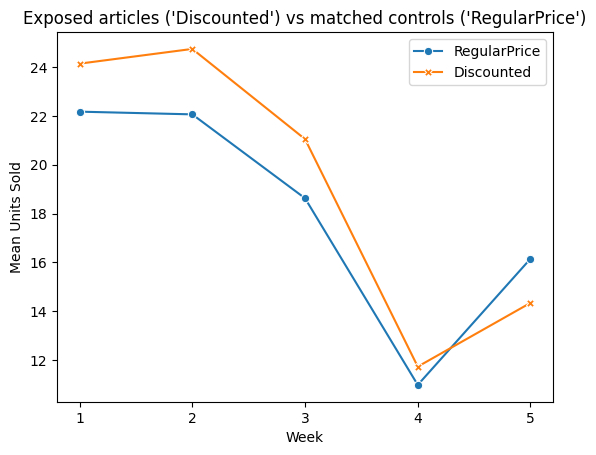

In [0]:
sns.lineplot(data=trend, x="week", y="mean_units", hue="group_label", style="group_label", markers=True, dashes=False)
plt.xlabel("Week")
plt.ylabel("Mean Units Sold")
plt.title("Exposed articles ('Discounted') vs matched controls ('RegularPrice')")
plt.xticks(list(range(1, treatment_week + 1)))
plt.legend(title="")
plt.show()